In [1]:
import jax
import jax.numpy as jnp

x = jnp.arange(10)
print(x)

[0 1 2 3 4 5 6 7 8 9]


In [2]:
y = jnp.arange(int(1e7))
%timeit jnp.dot(y, y).block_until_ready()

3.03 ms ± 108 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
def sum_of_squares(x):
    return jnp.sum(x ** 2)

sum_of_squares_dx = jax.grad(sum_of_squares)
x = jnp.asarray([1., 2., 3., 4.])
print(sum_of_squares(x))
print(sum_of_squares_dx(x))

30.0
[2. 4. 6. 8.]


In [4]:
def sum_squared_error(x, y):
    return jnp.sum((x - y) ** 2)

sum_squared_error_dx = jax.grad(sum_squared_error)
y = jnp.asarray([1.1, 2.1, 3.1, 4.1])
print(sum_squared_error_dx(x, y))

[-0.20000005 -0.19999981 -0.19999981 -0.19999981]


In [5]:
jax.grad(sum_squared_error, argnums=(0, 1))(x, y)

(Array([-0.20000005, -0.19999981, -0.19999981, -0.19999981], dtype=float32),
 Array([0.20000005, 0.19999981, 0.19999981, 0.19999981], dtype=float32))

In [6]:
# Los arrays se modifican con in place
x = jnp.array([5, 4, 3, 2])
x = x.at[1].set(10)
print(x)

[ 5 10  3  2]


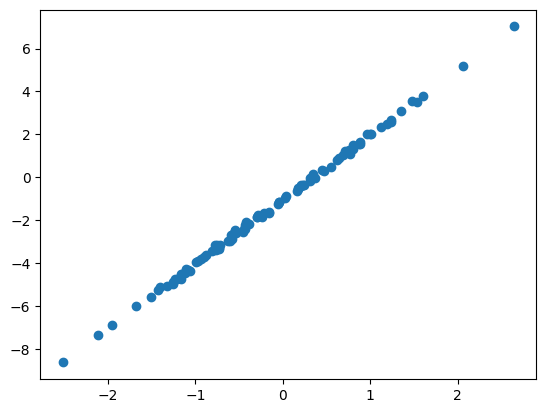

In [7]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.random.normal(size=(100, ))
noise = np.random.normal(scale=0.1, size=(100, ))
ys = 3 * xs - 1 + noise
plt.scatter(xs, ys)

In [8]:
def model(theta, x):
    w, b = theta
    return w * x + b

In [9]:
def loss_fn(theta, x, y):
    prediction = model(theta, x)
    return jnp.mean((prediction - y) ** 2)

In [11]:
def update(theta, x, y, lr=0.1):
    return theta - lr * jax.grad(loss_fn)(theta, x, y)

w: 3.008105754852295, b: -1.0254080295562744


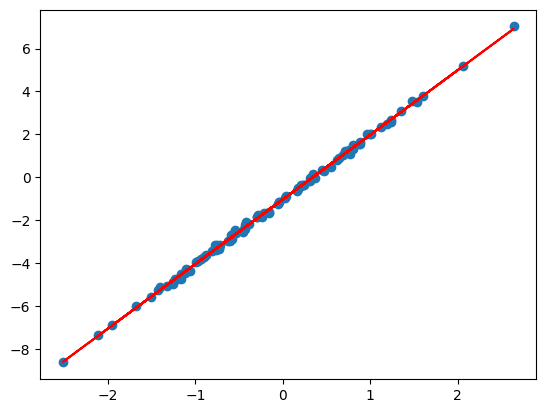

In [13]:
theta = jnp.array([1., 1.])
for _ in range(1000):
    theta = update(theta, xs, ys)

plt.scatter(xs, ys)
plt.plot(xs, model(theta, xs), color='r')

w, b = theta
print(f"w: {w}, b: {b}")